# Notebook 04 - LangGraph Agent

**Project:** IncidentIQ - AI-powered Incident Intelligence

**Goal:** Wire all five tools into a LangGraph agent with memory and LangSmith tracing.

## What this notebook covers
1. Install and import all required packages
2. Configuration and Pinecone initialization
3. LangSmith tracing setup
4. Load all tools
5. System prompt
6. Build LangGraph agent graph
7. ask() function with memory
8. Test single tool calls
9. Test multi-tool chain
10. Test conversation memory
11. Quality tests

---

## 1. Install required packages

In [1]:
!pip install langgraph langsmith langchain langchain-openai langchain-community langchain-text-splitters langchain-pinecone pinecone youtube-transcript-api reportlab google-api-python-client google-auth-oauthlib python-dotenv -q
print('Packages installed.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Packages installed.


## 2. Import libraries

In [2]:
import os
import re
import base64
import json
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv

from langchain.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from pinecone import Pinecone

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from youtube_transcript_api import YouTubeTranscriptApi, NoTranscriptFound, TranscriptsDisabled
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.lib.colors import HexColor, white
from reportlab.pdfgen import canvas
from googleapiclient.discovery import build
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders

load_dotenv()
assert os.getenv('OPENAI_API_KEY'), 'OPENAI_API_KEY not found.'
assert os.getenv('PINECONE_API_KEY'), 'PINECONE_API_KEY not found.'
print('Environment variables loaded.')

Environment variables loaded.


## 3. Configuration

In [3]:
INDEX_NAME        = 'incidentiq'
EMBEDDING_MODEL   = 'text-embedding-3-small'
LLM_MODEL         = 'gpt-4o-mini'
RETRIEVER_K       = 8
DISTRIBUTION_LIST = os.getenv('GMAIL_DISTRIBUTION_LIST', '').split(',')
GMAIL_SCOPES      = ['https://www.googleapis.com/auth/gmail.send']

RED    = HexColor('#C0392B')
DARK   = HexColor('#1C2833')
ORANGE = HexColor('#E67E22')
GREEN  = HexColor('#1E8449')
WHITE  = white

llm             = ChatOpenAI(model=LLM_MODEL, temperature=0)
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)
pc              = Pinecone(api_key=os.getenv('PINECONE_API_KEY'))
vectorstore     = PineconeVectorStore(
    index_name=INDEX_NAME,
    embedding=embedding_model,
    pinecone_api_key=os.getenv('PINECONE_API_KEY'),
)

print('Configuration set.')
print(f'   LLM:            {LLM_MODEL}')
print(f'   Pinecone index: {INDEX_NAME}')

Configuration set.
   LLM:            gpt-4o-mini
   Pinecone index: incidentiq


## 4. LangSmith tracing

LangSmith automatically logs every agent step.
Open smith.langchain.com during the demo to show the jury the agent thinking in real time.

In [4]:
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT']    = 'incidentiq-agent'

if os.getenv('LANGSMITH_API_KEY'):
    os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
    print('LangSmith tracing enabled.')
    print('   View traces at: https://smith.langchain.com')
    print('   Project: incidentiq-agent')
else:
    os.environ['LANGCHAIN_TRACING_V2'] = 'false'
    print('LangSmith disabled - add LANGSMITH_API_KEY to .env to enable.')

LangSmith tracing enabled.
   View traces at: https://smith.langchain.com
   Project: incidentiq-agent


## 5. Load all tools

All five tools from Notebook 03 are redefined here for a self-contained notebook.

In [5]:
def extract_video_id(url):
    if 'v=' in url: return url.split('v=')[1].split('&')[0]
    elif 'youtu.be/' in url: return url.split('youtu.be/')[1].split('?')[0]
    raise ValueError(f'Cannot extract video ID: {url}')

def clean_transcript(text):
    text = re.sub(r'\[Music\]|\[Applause\]|\[Laughter\]|\[Cheering\]', '', text)
    text = re.sub(r'\[\d{2}:\d{2}\]\s*(?=\[\d{2}:\d{2}\])', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_keypoints_for_pdf(context, language='dutch'):
    lang_map = {'dutch': 'Dutch', 'english': 'English', 'french': 'French'}
    lang = lang_map.get(language.lower(), 'Dutch')
    prompt = (
        f'Extract structured info for an incident cheatsheet in {lang}.\n'
        f'Return only this JSON: {{"title": "...", "subtitle": "...", '
        f'"keypoints": ["..."], "recommendations": ["..."]}}\n\n'
        f'Context:\n{context}\n\nJSON:'
    )
    raw = re.sub(r'```json|```', '', llm.invoke(prompt).content.strip()).strip()
    return json.loads(raw)

def generate_pdf(data, source_url=''):
    filepath = f'/tmp/incidentiq_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pdf'
    c = canvas.Canvas(filepath, pagesize=A4)
    W, H = A4
    c.setFillColor(RED)
    c.rect(0, H-3.2*cm, W, 3.2*cm, fill=1, stroke=0)
    c.setFillColor(WHITE)
    c.circle(1.8*cm, H-1.6*cm, 0.85*cm, fill=1, stroke=0)
    c.setFillColor(RED)
    c.setFont('Helvetica-Bold', 14)
    c.drawCentredString(1.8*cm, H-1.95*cm, 'IQ')
    c.setFillColor(WHITE)
    c.setFont('Helvetica-Bold', 15)
    c.drawString(3.2*cm, H-1.3*cm, data.get('title', 'IncidentIQ'))
    c.setFont('Helvetica', 10)
    c.drawString(3.2*cm, H-1.85*cm, data.get('subtitle', ''))
    c.setFont('Helvetica', 8)
    c.drawRightString(W-1.2*cm, H-1.3*cm, datetime.now().strftime('%d/%m/%Y'))
    c.drawRightString(W-1.2*cm, H-1.75*cm, 'Generated by IncidentIQ AI')
    c.setFillColor(ORANGE)
    c.rect(0, H-3.6*cm, W, 0.4*cm, fill=1, stroke=0)
    y = H-5.0*cm
    def sh(y, t, col=DARK):
        c.setFillColor(col); c.setFont('Helvetica-Bold', 11)
        c.drawString(1.2*cm, y, t.upper())
        c.setStrokeColor(col); c.setLineWidth(1.5)
        c.line(1.2*cm, y-0.2*cm, W-1.2*cm, y-0.2*cm)
        return y-0.7*cm
    def bi(y, txt, col=DARK, bc=RED):
        c.setFillColor(bc); c.circle(1.2*cm, y+0.2*cm, 0.1*cm, fill=1, stroke=0)
        c.setFillColor(col); c.setFont('Helvetica', 9.5)
        mw = W-1.5*cm-1.2*cm
        words = txt.split(); line, lines = '', []
        for w in words:
            t = line+w+' '
            if c.stringWidth(t,'Helvetica',9.5)<mw: line=t
            else: lines.append(line.strip()); line=w+' '
        lines.append(line.strip())
        for i,l in enumerate(lines): c.drawString(1.5*cm, y-i*0.45*cm, l)
        return y-len(lines)*0.45*cm-0.3*cm
    y = sh(y, 'Key Points', RED)
    for kp in data.get('keypoints',[]): y = bi(y, kp)
    y -= 0.4*cm
    y = sh(y, 'AI-generated recommendations', GREEN)
    c.setFillColor(HexColor('#EAFAF1')); c.setStrokeColor(GREEN); c.setLineWidth(0.8)
    c.roundRect(1.2*cm, y-0.75*cm, W-2.4*cm, 0.65*cm, 3, fill=1, stroke=1)
    c.setFillColor(GREEN); c.setFont('Helvetica-Bold', 8)
    c.drawString(1.55*cm, y-0.3*cm, 'AI analysis:')
    c.setFillColor(DARK); c.setFont('Helvetica-Oblique', 8)
    c.drawString(3.0*cm, y-0.3*cm, 'Automatically extracted from video - not cited from a person.')
    y -= 1.0*cm
    for rec in data.get('recommendations',[]): y = bi(y, rec, bc=GREEN)
    c.setFillColor(RED); c.rect(0, 1.2*cm, W, 0.15*cm, fill=1, stroke=0)
    c.setFillColor(DARK); c.rect(0, 0, W, 1.2*cm, fill=1, stroke=0)
    c.setFillColor(WHITE); c.setFont('Helvetica', 7.5)
    c.drawString(1.2*cm, 0.65*cm, 'IncidentIQ - AI-powered Incident Intelligence')
    if source_url: c.drawCentredString(W/2, 0.65*cm, f'Source: {source_url[:70]}')
    c.drawRightString(W-1.2*cm, 0.65*cm, 'Page 1/1')
    c.save()
    return filepath

def get_gmail_service():
    creds = None
    tp = Path('../token.json'); cp = Path('../credentials.json')
    assert cp.exists(), 'credentials.json not found.'
    if tp.exists(): creds = Credentials.from_authorized_user_file(str(tp), GMAIL_SCOPES)
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token: creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file(str(cp), GMAIL_SCOPES)
            creds = flow.run_local_server(port=0)
        tp.write_text(creds.to_json())
    return build('gmail', 'v1', credentials=creds)

print('Helper functions loaded.')

Helper functions loaded.


In [6]:
@tool
def fetch_youtube_transcript(youtube_url: str) -> str:
    """
    Fetch the transcript of a YouTube video and store it in Pinecone cloud.
    Use this tool when the user provides a YouTube URL.
    Checks Pinecone cache first - YouTube is only called once per video ever.
    Returns a confirmation with the number of chunks stored.
    """
    try:
        video_id = extract_video_id(youtube_url)
        index = pc.Index(INDEX_NAME)
        stats = index.describe_index_stats()
        if stats.total_vector_count > 0:
            test = vectorstore.similarity_search('incident', k=1)
            if test:
                return f'Video already in Pinecone knowledge base.\nVideo ID: {video_id}\nUsing cached data - no YouTube request needed.\nReady for Q&A.'
        try:
            entries = YouTubeTranscriptApi().fetch(video_id, languages=['en','nl','fr'])
            transcript_list = entries.snippets
        except NoTranscriptFound:
            return f'No transcript found for video {video_id}.'
        except TranscriptsDisabled:
            return f'Transcripts disabled for video {video_id}.'
        except Exception as e:
            return f'Could not fetch transcript. If YouTube blocks your IP wait 30-60 min.\nError: {str(e)}'
        plain = ' '.join(t.text for t in transcript_list)
        timestamped = ' '.join(f'[{int(t.start//60):02d}:{int(t.start%60):02d}] {t.text}' for t in transcript_list)
        plain = clean_transcript(plain)
        timestamped = clean_transcript(timestamped)
        splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
        chunks = splitter.create_documents(texts=[timestamped], metadatas=[{'video_id': video_id, 'source': youtube_url}])
        vectorstore.add_documents(chunks)
        return f'Transcript loaded.\nVideo ID: {video_id}\nChunks in Pinecone: {len(chunks)}\nReady for Q&A.'
    except Exception as e:
        return f'Error: {str(e)}'

@tool
def search_video_knowledge(query: str) -> str:
    """
    Search the Pinecone knowledge base for information relevant to the query.
    Use this tool to answer questions about the loaded video content.
    Uses query rewriting and multi-query for maximum retrieval quality.
    Automatically translates non-English queries for better results.
    Returns relevant transcript excerpts with timestamp sources.
    """
    try:
        english_query = llm.invoke(f'Translate to English, return only translation: {query}').content.strip()
        rewritten = llm.invoke(f'Rewrite for incident video search, max 20 words.\nQuery: {english_query}\nRewritten:').content.strip()
        try:
            response = llm.invoke(f'Generate 3 search query variations. Return JSON list of 3 strings.\nQuestion: {rewritten}\nJSON:').content.strip()
            queries = json.loads(re.sub(r'```json|```','',response).strip())
        except: queries = [rewritten]
        queries.append(rewritten)
        all_docs = {}
        for q in queries:
            for doc in vectorstore.similarity_search(q, k=4):
                key = doc.page_content[:100]
                if key not in all_docs: all_docs[key] = doc
        if not all_docs: return 'No relevant information found. Please load a YouTube video first.'
        combined = list(all_docs.values())
        all_ts = re.findall(r'\[\d{2}:\d{2}\]', ' '.join([d.page_content for d in combined]))
        seen, unique_ts = set(), []
        for t in all_ts:
            if t not in seen: seen.add(t); unique_ts.append(t)
        clean_chunks = [re.sub(r'\[\d{2}:\d{2}\]\s*(?=\[\d{2}:\d{2}\])', '', d.page_content) for d in combined]
        return '\n\n'.join(clean_chunks) + f'\n\nSources: {" | ".join(unique_ts[:5])}'
    except Exception as e:
        return f'Error: {str(e)}'

@tool
def summarize_video(language: str = 'english') -> str:
    """
    Generate a structured summary of the entire loaded video.
    Use this tool when the user asks for a full summary or overview.
    Specify language as english, dutch or french.
    Returns a structured summary with introduction, key points, lessons and conclusion.
    """
    try:
        results = vectorstore.similarity_search('main topic lessons learned conclusions', k=12)
        if not results: return 'No video content found. Please load a YouTube video first.'
        context = '\n\n'.join([re.sub(r'\[\d{2}:\d{2}\]\s*(?=\[\d{2}:\d{2}\])', '', r.page_content) for r in results])
        lang_map = {'english':'English','dutch':'Dutch - natural Belgian incident training language','french':'French'}
        lang = lang_map.get(language.lower(),'English')
        prompt = (f'Write a structured summary in {lang}.\n'
                  f'Structure: **Introduction** / **Key Points** / **Lessons Learned** / **Conclusion**\n'
                  f'Rules: bullet points only, max 15 words each, strictly from context.\n\nContext:\n{context}\n\nSummary:')
        return llm.invoke(prompt).content.strip()
    except Exception as e:
        return f'Error: {str(e)}'

@tool
def generate_pdf_cheatsheet(language: str = 'dutch', source_url: str = '') -> str:
    """
    Generate a professional 1-page PDF cheatsheet from the loaded video content.
    Use this tool when the user asks for a cheatsheet, key concepts document or PDF.
    Specify language as dutch, english or french.
    Returns the file path of the generated PDF for the Gmail tool to attach.
    """
    try:
        results = vectorstore.similarity_search('key points lessons recommendations conclusions', k=10)
        if not results: return 'No video content found. Please load a YouTube video first.'
        context = '\n\n'.join([r.page_content for r in results])
        data = extract_keypoints_for_pdf(context, language)
        filepath = generate_pdf(data, source_url)
        return f'PDF generated.\nFile path: {filepath}\nTitle: {data.get("title","N/A")}'
    except Exception as e:
        return f'Error: {str(e)}'

@tool
def send_gmail_with_cheatsheet(pdf_path: str, custom_emails: str = '') -> str:
    """
    Send the generated PDF cheatsheet to the distribution list via Gmail.
    Use this tool after generate_pdf_cheatsheet has created the PDF.
    pdf_path: file path returned by generate_pdf_cheatsheet.
    custom_emails: optional comma-separated emails added to the send list.
    Returns confirmation with full recipient list.
    """
    try:
        assert Path(pdf_path).exists(), f'PDF not found: {pdf_path}'
        recipients = [e.strip() for e in DISTRIBUTION_LIST if e.strip()]
        if custom_emails: recipients.extend([e.strip() for e in custom_emails.split(',') if e.strip()])
        assert recipients, 'No recipients. Add GMAIL_DISTRIBUTION_LIST to .env.'
        service = get_gmail_service()
        subject = f'IncidentIQ - Key Concepts Cheatsheet - {datetime.now().strftime("%d/%m/%Y")}'
        body = 'Dear colleague,\n\nPlease find attached the AI-generated key concepts cheatsheet.\n\nBest regards,\nIncidentIQ AI Agent'
        msg = MIMEMultipart()
        msg['From']='me'; msg['To']=', '.join(recipients); msg['Subject']=subject
        msg.attach(MIMEText(body,'plain'))
        with open(pdf_path,'rb') as f:
            part = MIMEBase('application','octet-stream'); part.set_payload(f.read())
        encoders.encode_base64(part)
        part.add_header('Content-Disposition',f'attachment; filename={Path(pdf_path).name}')
        msg.attach(part)
        message = {'raw': base64.urlsafe_b64encode(msg.as_bytes()).decode()}
        service.users().messages().send(userId='me',body=message).execute()
        return f'Sent successfully.\nRecipients: {", ".join(recipients)}'
    except Exception as e:
        return f'Error: {str(e)}'
    
@tool
def generate_xvr_scenario(language: str = 'dutch') -> str:
    """
    Generate a structured XVR simulation scenario brief
    based on the loaded incident video.
    Use this tool when the user asks to create an XVR scenario
    or clicks the Create XVR Scenario button.
    Returns a formatted scenario brief for XVR operators.
    """
    try:
        results = vectorstore.similarity_search(
            'location building fire cause complications decisions '
            'resources weather time casualties evacuation', k=12
        )
        if not results:
            return 'No video content found. Please load a YouTube video first.'

        context = '\n\n'.join([
            re.sub(r'\[\d{2}:\d{2}\]\s*(?=\[\d{2}:\d{2}\])', '', r.page_content)
            for r in results
        ])

        lang_map = {
            'dutch':   'Dutch - professional Belgian fire service terminology',
            'english': 'English',
            'french':  'French',
        }
        lang = lang_map.get(language.lower(), 'Dutch')

        prompt = (
            f'You are an expert XVR simulation scenario designer for emergency services.\n'
            f'Based on the incident described in the context, generate a complete\n'
            f'XVR operator scenario brief in {lang}.\n\n'
            f'Use this exact structure:\n\n'
            f'SCENARIO BRIEF — XVR SIMULATION\n'
            f'================================\n\n'
            f'INCIDENT TITLE:\n'
            f'[Short descriptive title]\n\n'
            f'LOCATION & BUILDING:\n'
            f'- Building type: [type]\n'
            f'- Floors: [number]\n'
            f'- Construction: [facade, materials]\n'
            f'- Address/area: [if mentioned]\n\n'
            f'INITIAL SITUATION T+00:00:\n'
            f'- Fire location: [exact location]\n'
            f'- Visibility: [smoke, flames]\n'
            f'- Known casualties: [number and location]\n'
            f'- First resources: [vehicles, personnel]\n\n'
            f'ENVIRONMENTAL CONDITIONS:\n'
            f'- Time of day: [if mentioned]\n'
            f'- Weather: [if mentioned]\n'
            f'- Special hazards: [materials, access]\n\n'
            f'SCENARIO COMPLICATIONS (inject in order):\n'
            f'- T+[time]: [complication 1]\n'
            f'- T+[time]: [complication 2]\n'
            f'- T+[time]: [complication 3]\n'
            f'- T+[time]: [complication 4]\n\n'
            f'CRITICAL DECISION MOMENTS:\n'
            f'1. [Decision moment with context]\n'
            f'2. [Decision moment with context]\n'
            f'3. [Decision moment with context]\n\n'
            f'LEARNING OBJECTIVES:\n'
            f'- [Objective 1]\n'
            f'- [Objective 2]\n'
            f'- [Objective 3]\n\n'
            f'DEBRIEFING QUESTIONS:\n'
            f'1. [Question based on actual mistakes]\n'
            f'2. [Question based on actual mistakes]\n'
            f'3. [Question based on actual mistakes]\n\n'
            f'XVR OPERATOR NOTES:\n'
            f'[Specific notes about key moments to inject]\n\n'
            f'Rules:\n'
            f'- Base everything strictly on the context\n'
            f'- Use realistic timings from the video\n'
            f'- Focus on what actually went wrong\n'
            f'- Never invent details not in the context\n\n'
            f'Context:\n{context}\n\nScenario brief:'
        )

        return llm.invoke(prompt).content.strip()

    except Exception as e:
        return f'Error generating XVR scenario: {str(e)}'


print('Tool 6 defined - generate_xvr_scenario')

AGENT_TOOLS = [
    fetch_youtube_transcript,
    search_video_knowledge,
    summarize_video,
    generate_pdf_cheatsheet,
    send_gmail_with_cheatsheet,
    generate_xvr_scenario,      # Tool 6 - XVR scenario generator
]

print(f'All {len(AGENT_TOOLS)} tools loaded.')
for i, t in enumerate(AGENT_TOOLS, 1):
    print(f'   Tool {i}: {t.name}')

Tool 6 defined - generate_xvr_scenario
All 6 tools loaded.
   Tool 1: fetch_youtube_transcript
   Tool 2: search_video_knowledge
   Tool 3: summarize_video
   Tool 4: generate_pdf_cheatsheet
   Tool 5: send_gmail_with_cheatsheet
   Tool 6: generate_xvr_scenario


## 6. System prompt

In [7]:
AGENT_SYSTEM_PROMPT = """You are IncidentIQ, an AI agent specialized in incident training and knowledge extraction.
You help emergency services professionals extract knowledge from incident training videos.
You work for any organization: fire services, police, EMS, civil protection.

You have access to these tools:
- fetch_youtube_transcript: load a YouTube video into the knowledge base
- search_video_knowledge: answer questions about the loaded video
- summarize_video: generate a structured summary
- generate_pdf_cheatsheet: create a 1-page PDF with key concepts
- send_gmail_with_cheatsheet: send the PDF to email addresses
- generate_xvr_scenario: generate a structured XVR simulation scenario brief for operators

HOW TO BEHAVE:
- YouTube URL detected -> call fetch_youtube_transcript
- Question about video -> call search_video_knowledge
- Summary requested -> call summarize_video
- Cheatsheet requested -> call generate_pdf_cheatsheet
- Send email requested -> call send_gmail_with_cheatsheet
- User asks for XVR scenario or clicks Create XVR Scenario -> call generate_xvr_scenario
- Multiple actions needed -> chain tools in correct order

LANGUAGE RULE:
- Always respond in the same language as the user message
- Dutch -> Dutch | English -> English | French -> French

FORMAT RULE:
- Always use bullet points - never paragraphs
- Max 15 words per bullet
- Confirm clearly what was done after tool calls
"""
print('System prompt defined.')

System prompt defined.


## 7. Build LangGraph agent graph

Two nodes connected by conditional edges:
- agent node: LLM that reads messages and decides what to do
- tools node: executes whichever tool the agent selected

MemorySaver stores the full conversation between turns using thread_id.

In [8]:
llm_with_tools = llm.bind_tools(AGENT_TOOLS)

def agent_node(state: MessagesState):
    """
    Agent node - the brain of the agent.
    Reads all messages and decides whether to call a tool or respond directly.
    """
    system   = SystemMessage(content=AGENT_SYSTEM_PROMPT)
    messages = [system] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

builder = StateGraph(MessagesState)
builder.add_node('agent', agent_node)
builder.add_node('tools', ToolNode(AGENT_TOOLS))
builder.add_edge(START, 'agent')
builder.add_conditional_edges('agent', tools_condition)
builder.add_edge('tools', 'agent')

memory = MemorySaver()
agent  = builder.compile(checkpointer=memory)

print('LangGraph agent compiled.')
print('   Nodes: agent, tools')
print('   Memory: MemorySaver per thread_id')

LangGraph agent compiled.
   Nodes: agent, tools
   Memory: MemorySaver per thread_id


## 8. Visualize the agent graph

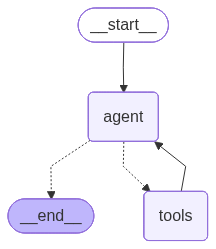

In [9]:
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print('Graph structure:')
    print('  START -> agent_node')
    print('  agent_node -> tools_node  (if tool call)')
    print('  agent_node -> END         (if final response)')
    print('  tools_node -> agent_node  (always loop back)')

## 9. Build the ask() function

Single entry point for all interactions.
Same thread_id = memory across turns.
New thread_id = fresh conversation.

In [10]:
def ask(message: str, thread_id: str = 'default', verbose: bool = False) -> str:
    """
    Send a message to the IncidentIQ agent and get a response.
    The agent autonomously decides which tools to call.
    
    Args:
        message:   Natural language message in any language
        thread_id: Session ID - same ID = memory across turns
        verbose:   If True show intermediate tool calls
    
    Returns:
        Agent final response as string
    """
    config = {'configurable': {'thread_id': thread_id}}
    inputs = {'messages': [HumanMessage(content=message)]}

    if verbose:
        print(f'Processing: "{message}"')
        print('-' * 50)

    final_response  = ''
    tool_calls_made = []

    for event in agent.stream(inputs, config=config, stream_mode='values'):
        last = event['messages'][-1]
        if verbose and hasattr(last, 'tool_calls') and last.tool_calls:
            for tc in last.tool_calls:
                tool_calls_made.append(tc['name'])
                print(f'   Calling: {tc["name"]}')
        if hasattr(last, 'content') and isinstance(last.content, str) and last.content.strip():
            final_response = last.content.strip()

    if verbose and tool_calls_made:
        print(f'   Tools used: {" -> ".join(tool_calls_made)}')
        print('-' * 50)

    return final_response

print('ask() function ready.')

ask() function ready.


## 10. Test single tool calls

In [11]:
VIDEO_URL = 'https://www.youtube.com/watch?v=7OH5FEWWM_k'

print('=' * 60)
print('TEST 1 - Load YouTube video')
print('=' * 60)
print(ask(VIDEO_URL, thread_id='t1', verbose=True))

print('\n' + '=' * 60)
print('TEST 2 - English question')
print('=' * 60)
ask(VIDEO_URL, thread_id='t2')
print(ask('What mistakes were made during the incident?', thread_id='t2', verbose=True))

print('\n' + '=' * 60)
print('TEST 3 - Dutch question')
print('=' * 60)
ask(VIDEO_URL, thread_id='t3')
print(ask('Welke fouten werden gemaakt tijdens het incident?', thread_id='t3', verbose=True))

print('\n' + '=' * 60)
print('TEST 4 - Dutch summary')
print('=' * 60)
ask(VIDEO_URL, thread_id='t4')
print(ask('Geef me een volledige samenvatting in het Nederlands', thread_id='t4', verbose=True))

print('\n' + '=' * 60)
print('TEST 5 - PDF cheatsheet')
print('=' * 60)
ask(VIDEO_URL, thread_id='t5')
print(ask('Maak een cheatsheet van de video in het Nederlands', thread_id='t5', verbose=True))

TEST 1 - Load YouTube video
Processing: "https://www.youtube.com/watch?v=7OH5FEWWM_k"
--------------------------------------------------
   Calling: fetch_youtube_transcript
   Tools used: fetch_youtube_transcript
--------------------------------------------------
The video transcript has been successfully loaded from the knowledge base. You can now ask questions about the video or request a summary, cheatsheet, or XVR scenario.

TEST 2 - English question
Processing: "What mistakes were made during the incident?"
--------------------------------------------------
   Calling: search_video_knowledge
   Tools used: search_video_knowledge
--------------------------------------------------
Here are the mistakes made during the incident:

- Crew thought they were at the fire floor but were actually below it.
- Assumed zero visibility conditions would be expected on the fire floor.
- Misjudged smoke conditions due to reverse stack effect.
- Lack of collaboration among different stations durin

## 11. Test multi-tool chain

The killer demo test — one natural language request triggers multiple tools in sequence.
The agent plans and executes all steps autonomously.

In [12]:
print('=' * 60)
print('TEST 6 - Multi-tool chain')
print('One request - agent chains multiple tools autonomously')
print('=' * 60)

ask(VIDEO_URL, thread_id='t6')
result = ask(
    'Maak een samenvatting en een cheatsheet van de video '
    'en stuur die naar jan@example.be en piet@example.be',
    thread_id='t6',
    verbose=True
)
print(f'\nFinal response:\n{result}')

TEST 6 - Multi-tool chain
One request - agent chains multiple tools autonomously
Processing: "Maak een samenvatting en een cheatsheet van de video en stuur die naar jan@example.be en piet@example.be"
--------------------------------------------------
   Calling: summarize_video
   Calling: generate_pdf_cheatsheet
   Calling: send_gmail_with_cheatsheet
   Tools used: summarize_video -> generate_pdf_cheatsheet -> send_gmail_with_cheatsheet
--------------------------------------------------

Final response:
De samenvatting van de video is als volgt:

**Inleiding**
- Incidenttraining in België richt zich op brandbestrijding en samenwerking.
- Belang van rookvrije omgevingen en effectieve communicatie.

**Belangrijke Punten**
- Mobiele risers moeten in rookvrije omgevingen worden ingezet.
- Verbeterde samenwerking tussen verschillende brandweerkorpsen is essentieel.
- Training in SCK (situational command knowledge) is noodzakelijk.
- Gebruik van thermische camera's is cruciaal voor situatio

## 12. Test conversation memory

In [13]:
print('=' * 60)
print('TEST 7 - Conversation memory')
print('=' * 60)

print('Turn 1 - load video')
r1 = ask(VIDEO_URL, thread_id='mem', verbose=True)
print(f'Agent: {r1}\n')

print('Turn 2 - question')
r2 = ask('Wat waren de drie grootste fouten?', thread_id='mem', verbose=True)
print(f'Agent: {r2}\n')

print('Turn 3 - follow-up using memory')
r3 = ask('Geef meer detail over de eerste fout die je noemde', thread_id='mem', verbose=True)
print(f'Agent: {r3}')

TEST 7 - Conversation memory
Turn 1 - load video
Processing: "https://www.youtube.com/watch?v=7OH5FEWWM_k"
--------------------------------------------------
   Calling: fetch_youtube_transcript
   Tools used: fetch_youtube_transcript
--------------------------------------------------
Agent: The video transcript has been successfully loaded from the knowledge base. You can now ask questions about the video or request a summary, cheatsheet, or XVR scenario.

Turn 2 - question
Processing: "Wat waren de drie grootste fouten?"
--------------------------------------------------
   Calling: search_video_knowledge
   Tools used: search_video_knowledge
--------------------------------------------------
Agent: De drie grootste fouten waren:

- Onvoldoende tijd om uitrusting aan te trekken.
- Aannames over rookverspreiding waren onjuist.
- Slechte coördinatie tussen verschillende teams.

Turn 3 - follow-up using memory
Processing: "Geef meer detail over de eerste fout die je noemde"
------------

## 13. Agent quality tests

In [14]:
print('=' * 60)
print('AGENT QUALITY TESTS')
print('=' * 60)

tests_passed = 0
tests_failed = 0

def check(name, condition, detail=''):
    global tests_passed, tests_failed
    if condition:
        tests_passed += 1
        print(f'  PASS - {name}')
    else:
        tests_failed += 1
        print(f'  FAIL - {name}')
    if detail: print(f'         {detail}')

VIDEO_URL = 'https://www.youtube.com/watch?v=7OH5FEWWM_k'

# Test 1 - Agent loads URL
r = ask(VIDEO_URL, thread_id='q1')
check('Agent detects YouTube URL and loads transcript',
    any(w in r.lower() for w in ['loaded','transcript','ready','video','cached']),
    f'Response: {r[:80]}...')

# Test 2 - English Q&A
ask(VIDEO_URL, thread_id='q2')
r = ask('What is this video about?', thread_id='q2')
check('Agent answers English question in English',
    len(r) > 50 and any(w in r.lower() for w in ['fire','incident','brussels','building']),
    f'Length: {len(r)} chars')

# Test 3 - Dutch Q&A
ask(VIDEO_URL, thread_id='q3')
r = ask('Waarover gaat deze video?', thread_id='q3')
check('Agent answers Dutch question in Dutch',
    len(r) > 50 and any(w in r.lower() for w in ['brand','incident','brussel','gebouw','de','het']),
    f'Length: {len(r)} chars')

# Test 4 - Summary
ask(VIDEO_URL, thread_id='q4')
r = ask('Geef me een volledige samenvatting in het Nederlands', thread_id='q4')
check('Agent generates structured summary',
    len(r) > 200 and ('**' in r or '-' in r),
    f'Length: {len(r)} chars')

# Test 5 - PDF
ask(VIDEO_URL, thread_id='q5')
r = ask('Maak een cheatsheet van de video', thread_id='q5')
check('Agent generates PDF cheatsheet',
    any(w in r.lower() for w in ['pdf','cheatsheet','aangemaakt','generated','created']),
    f'Response: {r[:80]}...')

# Test 6 - Memory
ask(VIDEO_URL, thread_id='q6')
ask('What went wrong?', thread_id='q6')
r = ask('What did you just tell me?', thread_id='q6')
check('Memory works across turns',
    any(w in r.lower() for w in ['incident','fire','brussels','mistake','wrong','building']),
    f'Response: {r[:80]}...')

# Test 7 - Fresh thread
r = ask('What video did we load?', thread_id='q7_fresh')
check('Fresh thread has no memory of other sessions',
    any(w in r.lower() for w in ['no video','load','provide','url','first','share']),
    f'Response: {r[:80]}...')

# Test 8 - Out of scope
ask(VIDEO_URL, thread_id='q8')
r = ask('What is the capital of France?', thread_id='q8')
check('Agent handles out-of-scope gracefully',
    len(r) > 10,
    f'Response: {r[:80]}...')

print('\n' + '=' * 60)
print(f'RESULTS: {tests_passed} passed | {tests_failed} failed')
if tests_failed == 0:
    print('All tests passed - agent ready for deployment!')
else:
    print('Fix failing tests before deployment.')
print('=' * 60)

AGENT QUALITY TESTS
  PASS - Agent detects YouTube URL and loads transcript
         Response: The video transcript has been successfully loaded from the knowledge base. You c...
  PASS - Agent answers English question in English
         Length: 1006 chars
  PASS - Agent answers Dutch question in Dutch
         Length: 283 chars
  PASS - Agent generates structured summary
         Length: 1253 chars
  PASS - Agent generates PDF cheatsheet
         Response: De cheatsheet is succesvol aangemaakt. 

- Titel: Incidentanalyse Brand in Bruss...
  PASS - Memory works across turns
         Response: I provided key points on what went wrong during the incident, including:

- Lack...
  PASS - Fresh thread has no memory of other sessions
         Response: I currently don't have access to the specific video that was loaded. Please prov...
  PASS - Agent handles out-of-scope gracefully
         Response: The video does not provide information about the capital of France. 

However, t...

RESULTS

---

## What we built

| Component | What | Why |
|-----------|------|-----|
| LangGraph graph | Two nodes + conditional edges | Autonomous tool selection |
| agent_node | LLM with all tools bound | Reads context, decides next action |
| tools_node | Executes selected tool | Runs fetch, search, summarize, PDF, Gmail |
| tools_condition | Router | Loops until agent satisfied |
| MemorySaver | Per thread_id | Remembers context across turns |
| LangSmith | Auto traces all steps | Live visualization during demo |
| Pinecone | Cloud vector DB | No local storage, no IP blocking |
